# Data Mining
Data mining entails sifting through extensive datasets with multiple dimensions to discover patterns and relationships that can be leveraged to address challenges.

# Multivariate Analysis

Multivariate analysis seeks to understand the relationships between the measured properties of the sample.

For multivariate datasets, we designate $n$ for the number of objects in the dataset and $p$ for the number of variables, the dimensionality of the problem. In traditional multivariate analysis, $n$ is large compared to $p$.

### The principal goals of multivariate analysis are to:

#### 1. quantify the location and distribution of the dataset in p-space (multivariate mean locations, variances and covariances, and fits to probability distributions);
#### 2. achieve structural simplification by reducing the number of variables without significant loss of scientific information by combining or omitting variables;
#### 3. investigate the dependence between variables;
#### 4. pursue statistical inference of many types including testing hypotheses, and calculating confidence regions for estimated parameters;
#### 5. classify or cluster “similar” objects into homogeneous subsamples
#### 6. predict the location of future objects - regression.


## Multivariate Normal Distribution

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
import numpy as np
import scipy

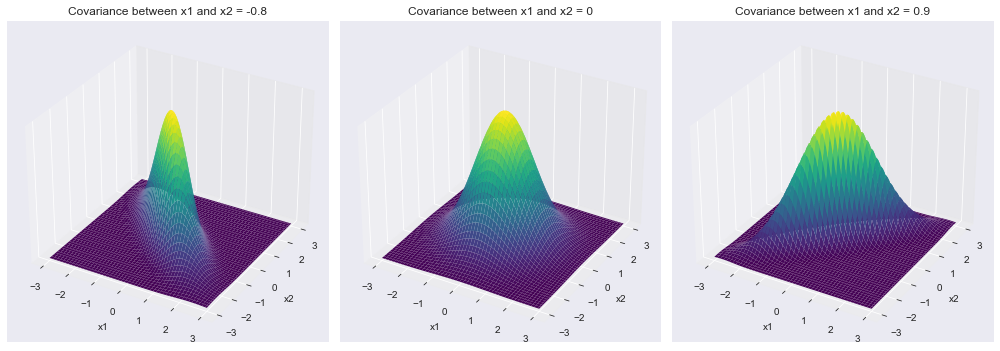

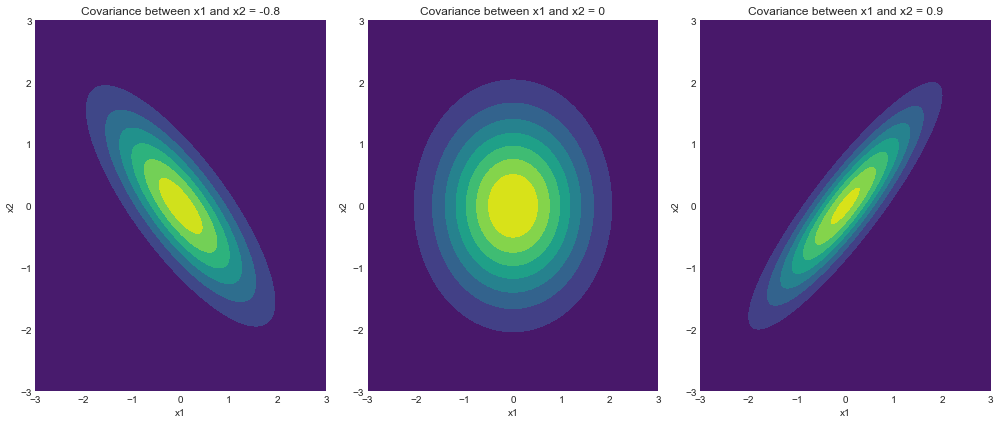

In [ ]:
plt.style.use('seaborn-dark')
plt.rcParams['figure.figsize']=14,6
fig = plt.figure()

# Initializing the random seed
random_seed=1000

# List containing the different variance
# covariance values
cov_val = [-0.8, 0, 0.9]

# Setting mean of the distributino
# to be at (0,0)
mean = np.array([0,0])

# Storing density function values for
# further analysis
pdf_list = []

# Iterating over different covariance values
for idx, val in enumerate(cov_val):

    # Initializing the covariance matrix
    cov = np.array([[1, val ], [val, 1]])

    # Generating a Gaussian bivariate distribution
    # with given mean and covariance matrix
    distr = multivariate_normal(cov = cov, mean = mean,
                                seed = random_seed)

    # Generating a meshgrid complacent with
    # the 3-sigma boundary
    mean_1, mean_2 = mean[0], mean[1]
    sigma_1, sigma_2 = cov[0,0], cov[1,1]

    x = np.linspace(-3*sigma_1, 3*sigma_1, num=100)
    y = np.linspace(-3*sigma_2, 3*sigma_2, num=100)
    X, Y = np.meshgrid(x,y)

    # Generating the density function
    # for each point in the meshgrid
    pdf = np.zeros(X.shape)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            pdf[i,j] = distr.pdf([X[i,j], Y[i,j]])

    # Plotting the density function values
    key = 131+idx
    ax = fig.add_subplot(key, projection = '3d')
    ax.plot_surface(X, Y, pdf, cmap = 'viridis')
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(f'Covariance between x1 and x2 = {val}')
    pdf_list.append(pdf)
    ax.axes.zaxis.set_ticks([])
plt.tight_layout()
plt.show()

# Plotting contour plots
for idx, val in enumerate(pdf_list):
    plt.subplot(1,3,idx+1)
    plt.contourf(X, Y, val, cmap='viridis')
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(f'Covariance between x1 and x2 = {cov_val[idx]}')
plt.tight_layout()
plt.show()


# Example of using Multivariate normal distribution to determine the confidence interval of the best fit model.

In [ ]:
def line(E,m,c):
    N = m*E + c
    return N

# Model function
n = 50 # no: of data points
E = np.linspace(1,100,n)

# Simulating fake dataset
m_ = np.random.normal(2,0.05)
c_ = np.random.normal(20,5)

n=50
N = line(E,m_,c_)
error = np.ones(n)*np.random.uniform(1,50,n)
Data = N +error+np.sqrt(N)
print('True value of parameters',m_, c_)

# Curve fitting
from scipy.optimize import curve_fit

xdata = E
ydata = Data

popt, pcov = curve_fit(line, xdata,ydata,p0=[1.8,24],maxfev=10000)
print('The fit values are popt',popt)
print('The covariance matrix',pcov)
error_m = (pcov[0,0])**0.5
error_c = (pcov[1,1])**0.5
print('The error on the parameters are',error_m,error_c)

True value of parameters 2.0574759287123516 13.287557573240784
The fit values are popt [ 2.05367425 46.16943568]
The covariance matrix [[ 5.08308080e-03 -2.56695581e-01]
 [-2.56695581e-01  1.72841865e+01]]
The error on the parameters are 0.07129572775103471 4.157425465003349


1.9104560395670502 2.1898402320030734
38.6523356401272 54.31521155152117
2.0508104525544724 46.35278217193489


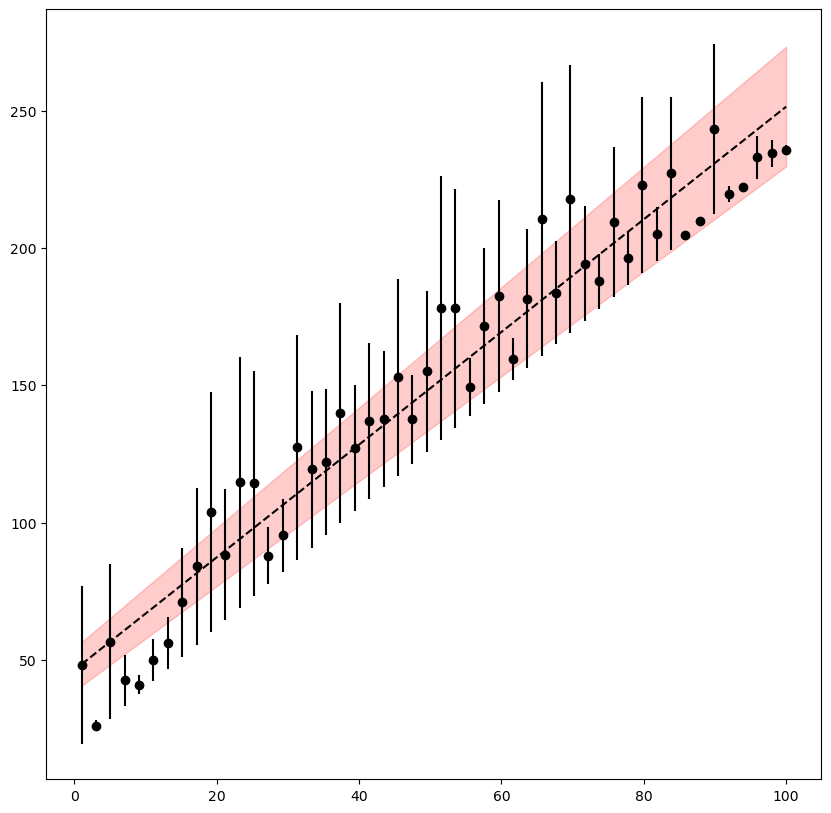

In [ ]:
n_samples=1000
# sample the pdf
samples = np.random.multivariate_normal(np.array(popt).T, pcov, n_samples)
p1 =samples[:,0]
p2 =samples[:,1]

# find the value at the confidence interval cl
cl =0.95
half_cl = cl / 2.0 * 100.0
low_bound_p1, high_bound_p1=np.percentile(p1, [50.0 - half_cl, 50.0 + half_cl])
low_bound_p2, high_bound_p2=np.percentile(p2, [50.0 - half_cl, 50.0 + half_cl])
p1_median= np.percentile(p1, 50)
p2_median= np.percentile(p2, 50)
print(low_bound_p1, high_bound_p1)
print(low_bound_p2, high_bound_p2)
print(p1_median, p2_median)

energies = np.linspace(1, 100, 100)
low_curve = np.zeros_like(energies)
middle_curve = np.zeros_like(energies)
hi_curve = np.zeros_like(energies)
for i, e in enumerate(energies):
    low_curve[i], middle_curve[i], hi_curve[i] = (line(e,low_bound_p1,low_bound_p2),line(e,p1_median,p2_median),line(e,high_bound_p1,high_bound_p2))

fig,ax=plt.subplots(figsize=(10,10))
ax.errorbar(E,Data,yerr=error,fmt='ko')
ax.plot(energies, middle_curve, "--", color="black")
ax.fill_between(energies, low_curve, hi_curve, alpha=0.2, color="red")
plt.show()

In [ ]:
pwd

'/Users/shabnamiyyani/Gamma_ray_burst Dropbox/Shabnam Iyyani/Teaching_Notes_IISER/PHY5132_6132_Statistical_and_data_analysis_in_Physical_Sciences'

In [ ]:
import pandas as pd
kk=pd.read_csv('/Users/shabnamiyyani/Gamma_ray_burst Dropbox/Shabnam Iyyani/Teaching_Notes_IISER/PHY5132_6132_Statistical_and_data_analysis_in_Physical_Sciences/Statistics_Modules/DataSets/Fermi_GBM_catalog_15_8_22.txt',delimiter="|",skipinitialspace=True,usecols=['t90     ','flnc_band_epeak','flnc_band_alpha'])
#usecols=['t90     ','flnc_band_epeak','flnc_band_alpha']
kk.info()

T90 = np.array(kk['t90     '])
Epeak = np.array(kk['flnc_band_epeak'])
alpha = np.array(kk['flnc_band_alpha'])

v1 = ~(np.isnan(Epeak) | np.isnan(T90) | np.isnan(alpha))

T90=T90[v1]
Epeak = Epeak[v1]
alpha = alpha[v1]
X=[Epeak,T90,alpha]
X=np.array(X)
print(X)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3340 entries, 0 to 3339
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   t90              3339 non-null   float64
 1   flnc_band_epeak  2308 non-null   float64
 2   flnc_band_alpha  2308 non-null   float64
dtypes: float64(3)
memory usage: 78.4 KB
[[ 1.928073e+02  1.288301e+02  2.261430e+02 ...  1.211838e+02
   8.046143e+01  4.215487e+02]
 [ 4.288000e+00  1.740800e+01  1.305600e+01 ...  5.555300e+01
   7.552000e+00  8.192000e+00]
 [-9.469590e-01 -8.071501e-01 -3.056635e-01 ... -1.073531e+00
  -1.249126e+00 -2.268140e-01]]


# Q-Q Plot

A **Q-Q plot** compares the quantiles (inverse of CDF) of a dataset against the quantiles of a theoretical distribution.

In other words,

## It compares data values and theoretical values at the same quantile level.


## How Quantiles are calculated for a theoretical pdf such as a normal distribution?

### Definition of the Quantile Function

### At what value of x does the cumulative probability reach p?

For e.g the quantiles are 0.25, 0.5, 0.9 ==> cumulative probability, p

For a continuous random variable \( X \) with cumulative distribution function (CDF) \( F(x) \), the **quantile function** is defined as:

$
q(p) = x = F^{-1}(p) = \inf \{ x \in \mathbb{R} \mid F(x) \geq p \}, \quad \text{for } p \in (0,1).
$

This means that for a given probability \( p \), the quantile function returns the value \( x \) such that:

$
P(X \leq x) = p.
$

For a normal distribution \( N(\mu, \sigma^2) \), the quantile function is given by:

$
q(p) = x = \mu + \sigma \cdot \Phi^{-1}(p),
$

where $ \Phi^{-1} $ is the inverse CDF of the standard normal distribution.

## How Quantiles are Calculated for a sample dataset

 The **quantile values** of a given dataset are estimated as follows:

#### **Step 1: Sort the Dataset**
Given a dataset \( X = \{x_1, x_2, ..., x_n\} \), sort the values in ascending order:
$
x_{(1)} \leq x_{(2)} \leq \dots \leq x_{(n)}
$
where \( x_{(i)} \) is the **i-th order statistic**.

#### **Step 2: Compute the Empirical Quantile Positions**
The quantile positions are computed as:
$
p_i = \frac{i - 0.5}{n}
$
where:
- \( i \) is the rank of the sorted value.
- \( n \) is the total number of observations.

This ensures quantiles are evenly spaced between \( 0 \) and \( 1 \).

#### **Step 3: Estimate the Sample Quantiles**
The sample quantiles are taken directly from the sorted dataset:
$
Q_{\text{data}}(p_i) = x_{(i)}
$

### **Example Calculation**

#### **Given dataset:**
Suppose we have a dataset:

$
X  \{ 5, 2, 9, 3, 7 \}
$

#### **Step 1: Sort the Dataset**
Sorting the dataset gives:

$
X_{\text{sorted}} = \{ 2, 3, 5, 7, 9 \}
$

#### **Step 2: Compute the Empirical Quantile Positions**
For a dataset of size \( n = 5 \), the quantile positions are:

$
p_i = \frac{i - 0.5}{n} = \left\{ \frac{0.5}{5}, \frac{1.5}{5}, \frac{2.5}{5}, \frac{3.5}{5}, \frac{4.5}{5} \right\}
$

which evaluates to:

$
p = \{ 0.1, 0.3, 0.5, 0.7, 0.9 \}
$

#### **Step 3: Estimate Sample Quantiles**
The sample quantiles are simply the sorted values at these positions:

| Rank $ i $ | $p_i $ (Quantile Position) | **Sample Quantile** $ Q_{\text{data}}(p_i) $ |
|-------------|-----------------------------|---------------------------------|
| 1           | 0.1                         | $ x_{(1)} = 2 $               |
| 2           | 0.3                         | $ x_{(2)} = 3 $               |
| 3           | 0.5                         | $x_{(3)} = 5 $               |
| 4           | 0.7                         | $ x_{(4)} = 7 $               |
| 5           | 0.9                         | $ x_{(5)} = 9 $               |

Thus, the **empirical quantiles** are:

$
Q_{\text{data}}(p) = \{2, 3, 5, 7, 9\}
$

---

**Theoretical quantiles for a Normal distribution**

### **Empirical vs. Theoretical Quantiles**

| Rank $ i $ | $ p_i $ (Quantile Position) | **Theoretical Normal Quantile** $ Q_{\text{normal}}(p_i) $ | **Sample Quantile** $ Q_{\text{data}}(p_i) $ |
|-------------|-----------------------------|---------------------------------|---------------------------------|
| 1           | 0.1                         |  -1.28                     | 2                          |
| 2           | 0.3                         |  -0.52                     | 3                          |
| 3           | 0.5                         |  0.00                      | 5                         |
| 4           | 0.7                         | 0.52                      |  7                          |
| 5           | 0.9                         |  1.28                     |  9                          |

- The **theoretical quantiles** $ Q_{\text{normal}}(p_i) $ are computed using the inverse CDF (percent-point function) of a standard normal distribution.
- The **sample quantiles** $ Q_{\text{data}}(p_i) $ are simply the sorted values of our dataset.






When the quantiles of two variables are plotted against each other, then the plot obtained is known as quantile – quantile plot or qqplot. This plot provides a summary of whether the distributions of two variables are similar or not with respect to the locations.

**If all point of quantiles lie on or close to straight line at an angle of 45 degree from x – axis. It indicates that two samples have similar distributions.**


### Comparing the quantiles of a given distribution to a distribution of choice

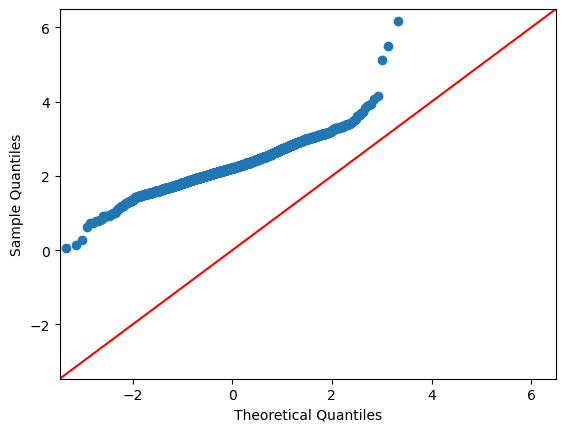

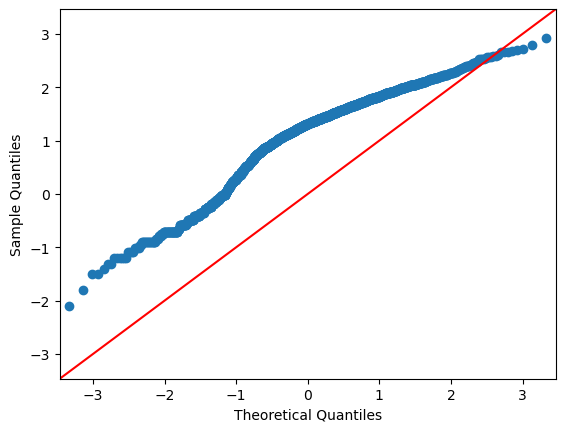

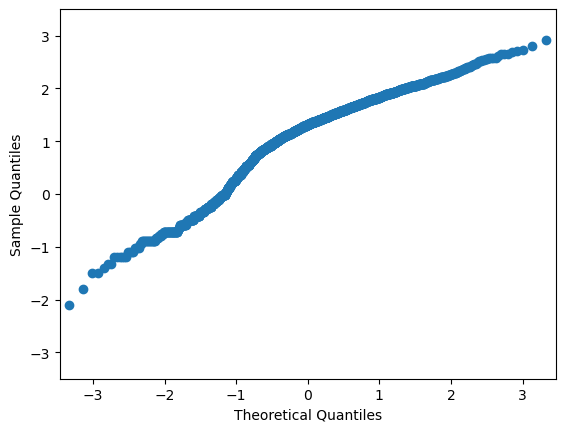

In [ ]:
import numpy as np
import statsmodels.api as sm
import pylab as py
import scipy.stats as stats

# Random data points generated
#data_points = np.random.normal(5, 1, 100)

sm.qqplot(np.log10(Epeak), line ='45') #Here it is default compared to the quantiles of a standard normal distribution.
sm.qqplot(np.log10(T90), line ='45')
sm.qqplot(np.log10(T90))
plt.ylim([-3.5, 3.5])
#sm.qqplot(data_points,stats.t,fit=True,line ='45')
py.show()

## Comparing the probabilities or quantiles of two datasets - PP Plot

## It compares the empirical cumulative probability of each data point with the theoretical cumulative probability evaluated at that same data value.

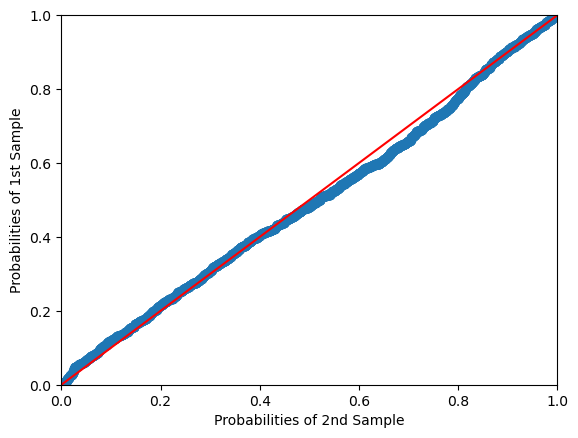

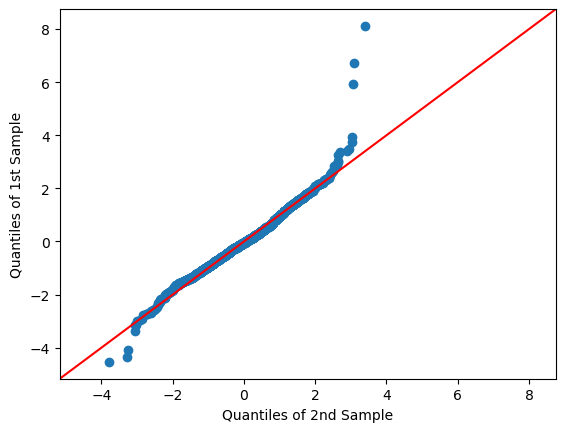

In [ ]:
#x = np.random.normal(loc=8.25, scale=3.5, size=50)
y = np.random.normal(loc=5, scale=4., size=len(Epeak))
pp_x = sm.ProbPlot(np.log10(Epeak), fit=True) # Generated empirical cumulative distribution of the sample, the default dist is standard normal
pp_y = sm.ProbPlot(y, fit=True)
fig3 = pp_x.ppplot(other=pp_y, line='45')

# compare x quantiles to y quantiles
fig4 = pp_x.qqplot(other=pp_y, line='45')


### **Difference Between Q-Q Plot and P-P Plot**
| Feature           | Q-Q Plot (Quantile-Quantile Plot) | P-P Plot (Probability-Probability Plot) |
|------------------|---------------------------------|---------------------------------|
| **Definition**   | Compares quantiles of the sample distribution with the theoretical distribution. | Compares cumulative probabilities (CDF values) of the sample and theoretical distribution. |
| **X-axis**       | Theoretical quantiles from a reference distribution (e.g., normal distribution). | Theoretical cumulative probabilities from a reference distribution. |
| **Y-axis**       | Empirical quantiles from the sample data. | Empirical cumulative probabilities from the sample data. |
| **Usage**        | Checks if the sample follows a specific theoretical distribution. | Checks if the cumulative probabilities of two distributions match. |
| **Interpretation** | If the points fall along the diagonal $ y = x $, the distributions are similar in shape. | If the points fall along $ y = x $, the two distributions have the same cumulative probabilities. |
| **Sensitivity**   | Detects deviations in **tails** (extremes) of distributions. | More sensitive to **differences in the middle** of distributions. |
| **Best Used For** | Checking normality, heavy-tailed or skewed distributions. | Assessing goodness of fit between two distributions. |



### Relationship or studying correlation between parameters
## Scatter Plot

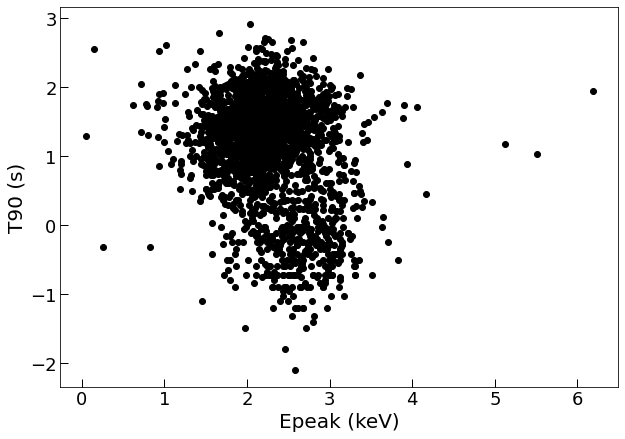

In [ ]:
fig_scatter,ax2 = plt.subplots(figsize =(10, 7))
ax2.plot(np.log10(Epeak),np.log10(T90),'ko')
#ax2.set_xscale('log')
#ax2.set_yscale('log')
#plt.ylim([-3,4])
ax2.tick_params(axis='both',which='both', width=1,direction='in')
ax2.tick_params(which='major', length=8)
ax2.tick_params(which='minor', length=4)
ax2.tick_params(axis='x', labelsize=18)
ax2.tick_params(axis='y', labelsize=18)
ax2.set_ylabel('T90 (s)',fontsize=20)
ax2.set_xlabel('Epeak (keV)',fontsize=20)
plt.show()

# Kernel Density Estimate

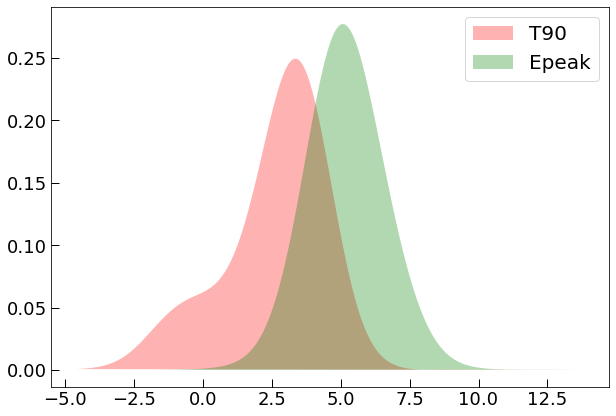

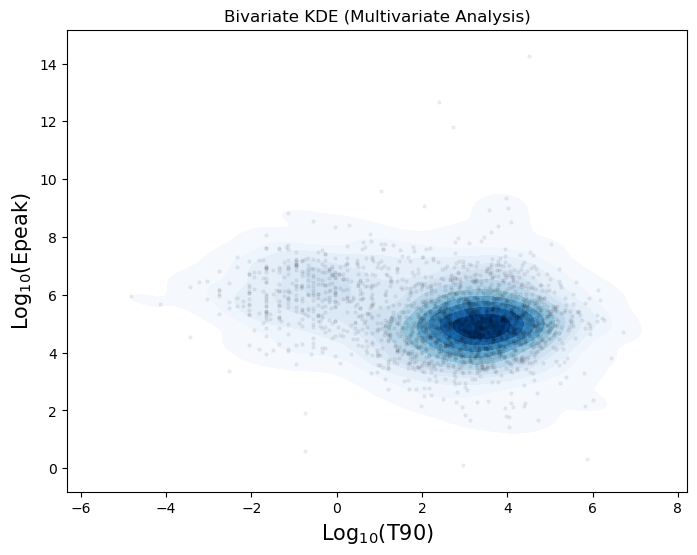

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Extract x and y datasets
x, y = np.array(np.log(T90)), np.array(np.log(Epeak))

# Plot the KDE heatmap using seaborn
plt.figure(figsize=(8, 6))
#using raw density values
sns.kdeplot(x=x, y=y, cmap="Blues", fill=True,levels=[0.01, 0.05, 0.1, 0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.999])  # Corrected argument passing
#Scatter plot
plt.scatter(x, y, s=5, color="black", alpha=0.05)
# Overlay scatter plot
plt.title("Bivariate KDE (Multivariate Analysis)")
plt.xlabel("Log$_{10}$(T90)",fontsize=15)
plt.ylabel("Log$_{10}$(Epeak)",fontsize=15)
plt.show()


## If you don’t specify levels, Seaborn automatically selects 10 equally spaced density values between the minimum and maximum of the estimated PDF. Here it is based on raw density values.
## If you specify levels manually (e.g., levels=[0.01, 0.05, 0.1, 0.2]), these values represent specific density values of the KDE.
This does not mean 1% of the data is inside—it means the estimated probability density function (PDF) at that contour is 0.01.

### Each contour line encloses a region where all (X, Y) points share the same estimated density value. The innermost contours represent higher density regions (most probable locations), while the outer contours enclose broader, lower-density areas.


### How Colors Represent Density Levels
The innermost contour represents the highest density, and the colors fade outward as density decreases.

High density --> Darker colors.

Low density ---> Lighter colors.

# Corner Plot

Refer to the documentation on corner plot (https://corner.readthedocs.io/en/latest/install/).
In particular read about the note on sigmas in 2D histograms and 2D contour plots (https://corner.readthedocs.io/en/latest/pages/sigmas/)

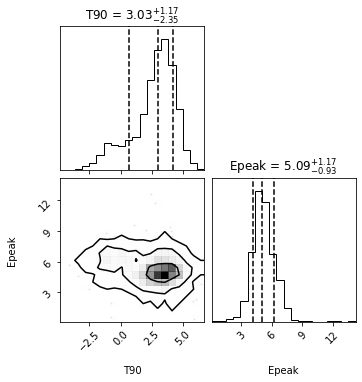

In [ ]:
import corner
Array = np.array([np.array(np.log(T90)),np.array(np.log(Epeak))]).T

fig = corner.corner(Array, labels=['T90','Epeak'],quantiles=[0.16, 0.5, 0.84],show_titles=True,levels=((1 - np.exp(-(1)**2 /2)), (1 - np.exp(-(2)**2 /2)), (1 - np.exp(-(3)**2 /2))))


## Scatter Matrix

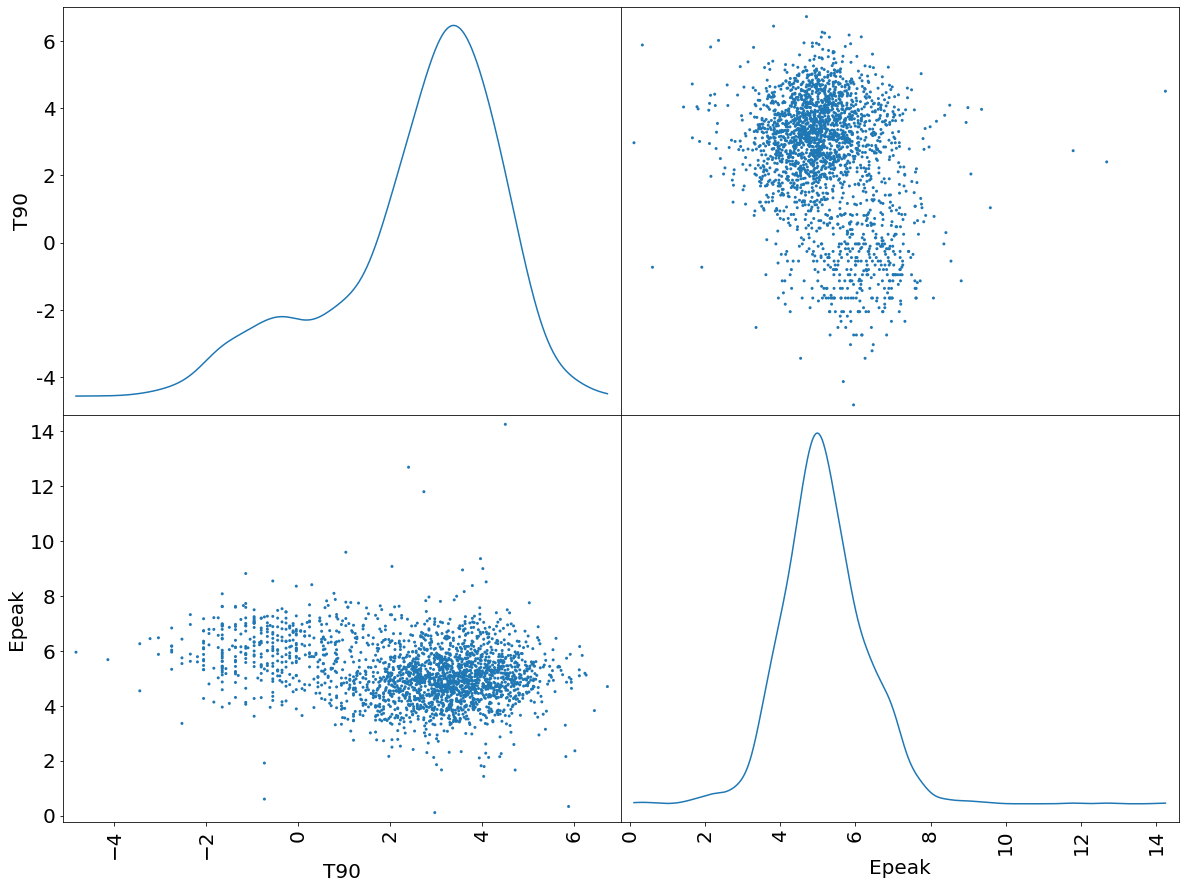

In [ ]:
df=pd.DataFrame(Array, columns=['T90','Epeak']) #convert the numpy array into a pandas dataframe
Plot=pd.plotting.scatter_matrix(df, diagonal="kde",figsize=(20,15),alpha=1.0)  #diagonal="hist"
for ax in Plot.ravel():
    ax.set_xlabel(ax.get_xlabel(), fontsize = 20, rotation = 0)
    ax.set_ylabel(ax.get_ylabel(), fontsize = 20, rotation = 90)
    ax.tick_params(axis='x', labelsize=20)
    ax.tick_params(axis='y', labelsize=20)
plt.show()

## Generating the Correlation Matrix

In [ ]:
df=pd.DataFrame(kk)
corrmat = df.corr()
print(corrmat)

                 t90       flnc_band_epeak  flnc_band_alpha
t90              1.000000         0.014275        -0.134370
flnc_band_epeak  0.014275         1.000000        -0.030587
flnc_band_alpha -0.134370        -0.030587         1.000000


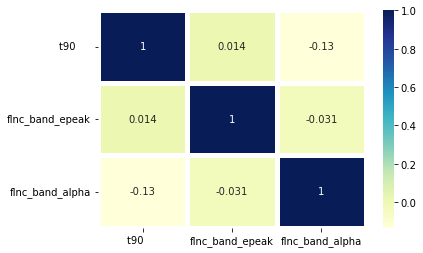

In [ ]:
sns.heatmap(df.corr(), cmap="YlGnBu", annot=True,linewidth=5);

# Principal Component Analysis
Reference (https://www.youtube.com/watch?v=FgakZw6K1QQ) by Josh Starmer

PCA is an unsupervised statistical machine learning technique used to examine the interrelations among a set of variables.

For example in the Fermi GRB catalog, each GRB has a number of attributes such as Epeak, alpha, T90, fluence etc. We can study the correlation between these characteristics by plotting Epeak versus alpha, Epeak versus T90, Epeak versus fluence etc. or by plotting combined 4 dimensional plots. Both are very difficult to visualise and make some sense about the behaviour patterns among the GRBs taking into consideration all the parameters together.

This becomes possible in principal component analysis.

When we draw a principal component analysis plot (PCA)

![Screenshot%202022-10-31%20at%2011.39.27%20PM.png](attachment:Screenshot%202022-10-31%20at%2011.39.27%20PM.png)

A PCA plot converts the correlation between the different GRBs into a 2D graph. **This is referred to as dimensionality reduction technique.** The GRBs that are highly correlated cluster together.

While interpreting the PCA plot, the axes are ranked in order of importance. It means, the differences between clusters or samples of GRBs along the axes PC1 is more important than that on the axes PC2. Similarly, the differences between clusters or samples of GRBs along the axes PC2 is more important than that on the axes PC3.
In other words, if the difference between cluster A and cluster B along PC1 and difference between cluster A and cluster C along PC2 are same, then it should be understood that the clusters A and B are more different from/ similar to each other than cluster A and cluster C.

The principal components are eigenvectors of the data's covariance matrix.

PCA analysis technique:

- In the first step in PCA calculation, we calculate the average of each column data. Thus, we get the centre of the data.
- we then shift the entire data such that the centre of the data is at the origin. This does not change the relative position of each data point with respect to each other.
- If the dataset, involves features are on different scales, PCA should be applied after standardization to avoid some variables dominating others. If all features have similar scales, only centering is enough.
Standardization of data of feature X involves both centering and scaling:

## $
X' = \frac{X - \mu}{\sigma}
$

where:
- $ X' $ = Standardized value  
- $ X $ = Original value  
- $ \mu $ = Mean of the feature  
- $ \sigma $ = Standard deviation of the feature  

This ensures all features have zero mean and unit variance.
- Through the standardised dataset, a line is fitted such that it passes through the origin.
- How does the PCA decides which line is best or not? For this the PCA projects the data on to the line (passing through the origin) and finds the best fit line such that it maximises the sum of the square of the distances to the projected data points from the origin (This is equal to minimising the distance of the data point to the line). - The sum of the square of the distances of the projected points on the best fit line from the origin is referred to as the eigen value of the PC1. The vector corresponding to the slope of the best fit such that the length of the vector is scaled to 1 unit is referred to as the eigen vector of the PC1 or singular vector of PC1.
**Thus, the PC components are the linear combination of the variables.**   
- PC2 is the line perpendicular to the PC1 and passes through the origin. Similarly, PC3 is the line perpendicular to both PC1 and PC2 and passes through the origin. This continues until we obtain as many principal components as there are original features.
- Variance of each PC is estimated by its eigen values/(length of data - 1).
- Percentages of variance of each PC is found by variance of PC divided by the total variances of all PCs. The graphical representation of the percentage of variance of each PC as a bar plot is referred to as scree plot.
- A PC plot includes the 2-D scatter plot of data with the principal components with the highest variances that is PC1 and PC2 as the x and y axes.  

## In PCA, the eigenvector gives the direction of the principal component (line through the origin that maximizes variance), and the corresponding eigenvalue gives the variance of the data projected along that direction.

For the 3340 GRBs, we are interested in its 3 features: Epeak, T90 and alpha

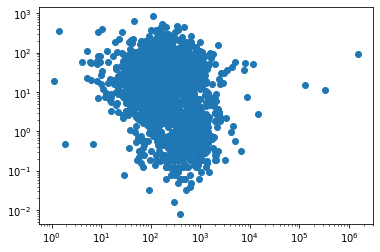

In [ ]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(Epeak, T90)
plt.xscale('log')
plt.yscale('log')
plt.show()

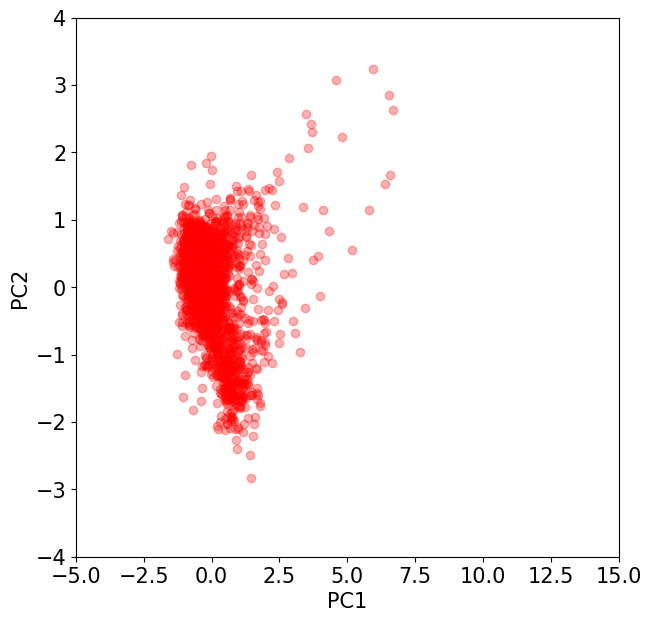

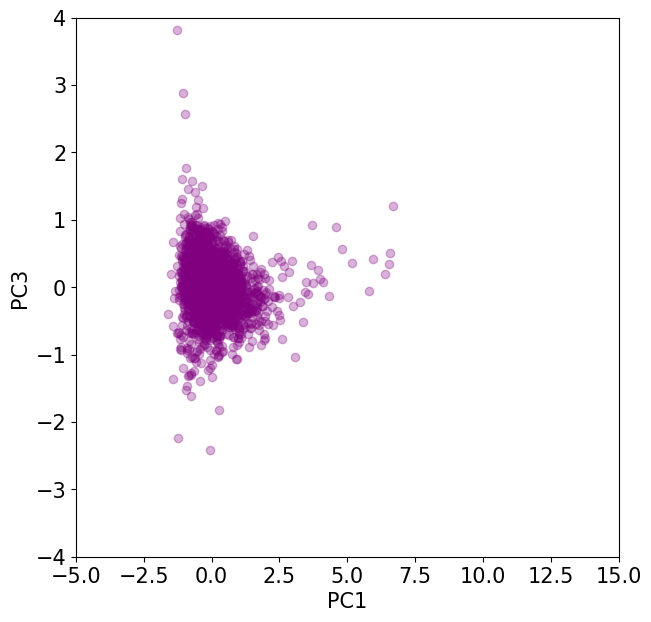

55.7598850929912 32.931657963517765 11.308456943491038


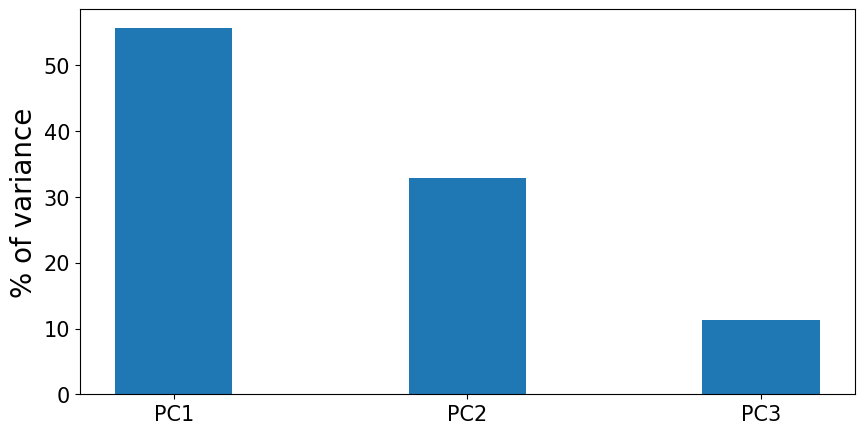

Eigen vectors are [[-0.94581971 -0.32453131 -0.01022252]
 [-0.28659165  0.84921774 -0.4435025 ]
 [-0.15261159  0.41654372  0.89621484]]
Eigen values are [0.19597404 0.57070121 0.96631132]
Percentage Variances are 11.308456943491041 32.93165796351776 55.759885092991205


In [ ]:
from sklearn.decomposition import PCA
X=[np.log10(Epeak),np.log10(T90),alpha]
X=np.array(X).T
#print(X)

Xt = PCA().fit_transform(X)
#print(Xt)
plt.figure(figsize=(7,7))
plot = plt.scatter(Xt[:,0],Xt[:,1],color='red',alpha=0.3)
plt.xlim(-5,15)
plt.ylim(-4,4)
plt.tick_params(axis='x', labelsize=15)
plt.tick_params(axis='y', labelsize=15)
plt.xlabel('PC1',fontsize=15)
plt.ylabel('PC2',fontsize=15)

plt.show()

plt.figure(figsize=(7,7))
plot = plt.scatter(Xt[:,0],Xt[:,2],color='purple',alpha=0.3)
plt.xlim(-5,15)
plt.ylim(-4,4)
plt.tick_params(axis='x', labelsize=15)
plt.tick_params(axis='y', labelsize=15)
plt.xlabel('PC1',fontsize=15)
plt.ylabel('PC3',fontsize=15)

plt.show()

## Estimating the variances of the data in different PC
var_pc1 = np.divide(np.sum(np.power(Xt[:,0],2)),len(Xt[:,0]) -1)
var_pc2 = np.divide(np.sum(np.power(Xt[:,1],2)),len(Xt[:,1]) -1)
var_pc3 = np.divide(np.sum(np.power(Xt[:,2],2)),len(Xt[:,2]) -1)
pervar_pc1 = var_pc1*100/(var_pc1+var_pc2+var_pc3 )
pervar_pc2 = var_pc2*100/(var_pc1+var_pc2+var_pc3 )
pervar_pc3 = var_pc3*100/(var_pc1+var_pc2+var_pc3 )
print(pervar_pc1,pervar_pc2,pervar_pc3)

### creating the scree plot which tells you each PC has how much % of the variance of the data
fig = plt.figure(figsize = (10, 5))
plt.bar(['PC1','PC2','PC3'], [pervar_pc1,pervar_pc2,pervar_pc3],width = 0.4)
plt.ylabel("% of variance",fontsize=20)
plt.tick_params(axis='x', labelsize=15)
plt.tick_params(axis='y', labelsize=15)
plt.show()



#For estimating the Eigen values and vectors
M = np.mean(X.T, axis=1)
C = X - M
V = np.cov(C.T)

values, vectors = np.linalg.eig(V)

var = values/(len(Xt[:,0])-1)
print('Eigen vectors are',vectors)
print('Eigen values are',values)
print('Percentage Variances are',var[0]/(np.sum(var))*100, var[1]/(np.sum(var))*100,var[2]/(np.sum(var))*100)

### **Aim of Principal Component Analysis (PCA)**

PCA is a dimensionality reduction technique with the following key objectives:

1. **Reduce Dimensionality**  
   - Transform high-dimensional data into a lower-dimensional space while retaining important information.

2. **Capture Maximum Variance**  
   - Identify the directions (principal components) that capture the most variance in the data.

3. **Remove Redundancy (Correlation Reduction)**  
   - Convert correlated features into a set of uncorrelated principal components.

4. **Improve Computational Efficiency**  
   - Simplify large datasets for faster processing in machine learning models.

5. **Enhance Data Visualization**  
   - Reduce complex datasets (e.g., 3D, 4D, or higher) into 2D or 3D for easy visualization.

6. **Noise Reduction**  
   - Filter out less significant variations that may be due to noise rather than actual data patterns.

7. **Feature Extraction**  
   - Transform raw features into a smaller set of meaningful derived features.

## PCA is widely used in **data preprocessing, pattern recognition, image processing, and exploratory data analysis.**


[[1 7]
 [3 4]
 [9 6]
 [8 6]]
[5.25 5.75]
[[-4.25  1.25]
 [-2.25 -1.75]
 [ 3.75  0.25]
 [ 2.75  0.25]]
[[14.91666667  0.08333333]
 [ 0.08333333  1.58333333]]
Eigen vectors are [[ 0.99998047 -0.00624963]
 [ 0.00624963  0.99998047]]
Eigen values are [14.91718748  1.58281252]
[[-4.24210496  1.27653653]
 [-2.26089292 -1.73590415]
 [ 3.75148917  0.22655899]
 [ 2.7515087   0.23280862]]


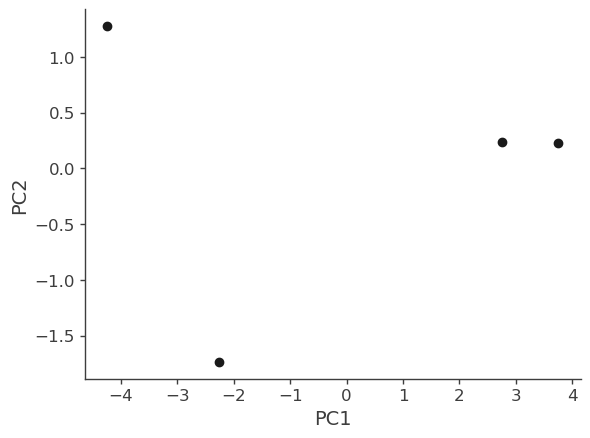

In [ ]:
from numpy import array
from numpy import mean
from numpy import cov
from numpy.linalg import eig
# define a matrix
A = array([[1, 7], [3, 4], [9, 6],[8, 6]])  #There are three columns of data
print(A)
# calculate the mean of each column # in the first step in PCA calculation what we do is calculate the average of each column data.
M = mean(A.T, axis=1) # Thus we get the centre of the data
print(M)
# center columns by subtracting column means # in other words, we shift the entire data
#such that the centre of the data is at the origin
C = A - M
print(C)


#Estimate the principal components
# calculate covariance matrix of centered matrix
V = cov(C.T)
print(V)
# eigendecomposition of covariance matrix
values, vectors = eig(V)
print('Eigen vectors are',vectors)
print('Eigen values are',values)
# project data
P = vectors.T.dot(C.T)
print(P.T)

import matplotlib.pyplot as plt
plt.figure()
plt.plot(P.T[:,0],P.T[:,1],'ko')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()